<h1>Assignment 3: <strong> Regularization and Optimization</strong></h1>
Name : Sammit Poudyal <br/>
Class : CE 2022<br/>
Registration Number : 032329-22<br>
Date : 18/04/2026<br/>
Dataset Used :<strong> Fashion-MNIST </strong><br/>


## 1. Objective

We focus on how regularization techniques and optimizer choices affect model generalization on an image classification task. The goals/objectives for this practical assignment are:

- To demonstrate overfitting using a baseline model with no regularization.
- To compare L1 and L2 regularization (weight decay) against the unregularized baseline.
- To evaluate Dropout as a structural regularization technique.
- To examine Batch Normalization and its effect on training stability and generalization.
- To compare optimizers (SGD, Adam) in terms of convergence speed and final validation accuracy.


## 2. Theoretical Background

### 2.1 Overfitting & Generalization
A model overfits when it memorizes training data rather than learning generalizable patterns, resulting in low training loss but high validation loss. Overfitting happens when the model is too good at learning from the training data but not so good at generalizing to new data. Regularization techniques help to prevent overfitting by adding a penalty term to the loss function, which discourages the model from becoming too complex.

### 2.2 L1 & L2 Regularization
L1 and L2 regularization are techniques used to prevent overfitting in machine learning by adding a penalty term to the loss function to encourage simpler models. L1 (Lasso) adds the absolute value of coefficients, forcing some to zero for feature selection, while L2 (Ridge) adds squared magnitudes, shrinking weights evenly.

$$\mathcal{L}_{total} = \mathcal{L}_{task} + \lambda \cdot \Omega(W)$$
- **L1 (Lasso):** $\Omega(W) = \sum |w_i|$ — encourages sparsity; some weights become exactly zero. Must be manually added to the loss.
- **L2 (Ridge):** $\Omega(W) = \sum w_i^2$ — penalizes large weights, encouraging small distributed values. Implemented via 'weight_decay' in PyTorch optimizers.


### 2.3 Dropout
During training, randomly sets a fraction $p$ of neuron activations to zero:
$$\tilde{h} = h \cdot \text{Bernoulli}(1-p) / (1-p)$$
This forces the network to learn redundant representations. Dropout Regularization helps overcome overfitting by randomly deactivating a portion of neurons during training hence forcing the model to learn more robust and independent features.



### 2.4 Batch Normalization
Normalizes activations within each mini-batch:
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta$$
This stabilizes training, allows higher learning rates, and has a mild regularizing effect. It works by normalizing the data within each mini-batch. This means it calculates the mean and variance of data in a batch and then adjusts the values so that they have similar range. After that it scales and shifts the values so that model learn effectively.

### 2.5 Optimizers
- **SGD (+ Momentum):** Updates weights using gradient estimates. Simple, but requires careful LR tuning. Momentum accelerates convergence. The optimizer gains speed in the right direction, reducing the likelihood of getting caught in minor fluctuations, leading to faster and smoother convergence.
- **Adam:** Adapts learning rates per parameter using first and second moment estimates. Generally converges faster but may generalize slightly worse.. It works well with large datasets and complex models because it uses memory efficiently and adapts the learning rate for each parameter automatically.
<br/>
<br/>

## 3. Dataset Description
Name: FashionMNIST<br>
Source: Zalando Research / `torchvision.datasets` <br/>
Samples: 70,000 grayscale images (28×28) in 10 classes.<br/>
Classes: 10 (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot) <br/>
Split: 60k train / 10k validation from training set(random-split) / 10k test.<br/>
Normalization: Mean=0.2860, Std=0.3530.<br>

## 4. Implementation

### 4.1 Setup

In [1]:
#  Standard Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

#setting seeds for reproducibility
SEED = 55
torch.manual_seed(SEED)
np.random.seed(SEED)

#  Device config test and pytorch version check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0


### 4.2 Dataset Loading and Preprocessing

In [2]:
#  Hyperparameters
BATCH_SIZE  = 256
NUM_EPOCHS  = 30
LEARNING_RATE = 0.001
VAL_SPLIT   = 10000    # samples held out from training for validation

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle Boot']

#  Transforms (FashionMNIST channel stats)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

#  Download & Spliting the dataset
full_train = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_set = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# Train / Validation split formation
train_set, val_set = random_split(
    full_train, [len(full_train) - VAL_SPLIT, VAL_SPLIT],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

#printing dataset statistics after preprocessing
print(f"Training samples  : {len(train_set):,}")
print(f"Validation samples: {len(val_set):,}")
print(f"Test samples      : {len(test_set):,}")

Training samples  : 50,000
Validation samples: 10,000
Test samples      : 10,000


### 4.3 Dataset Visualisation

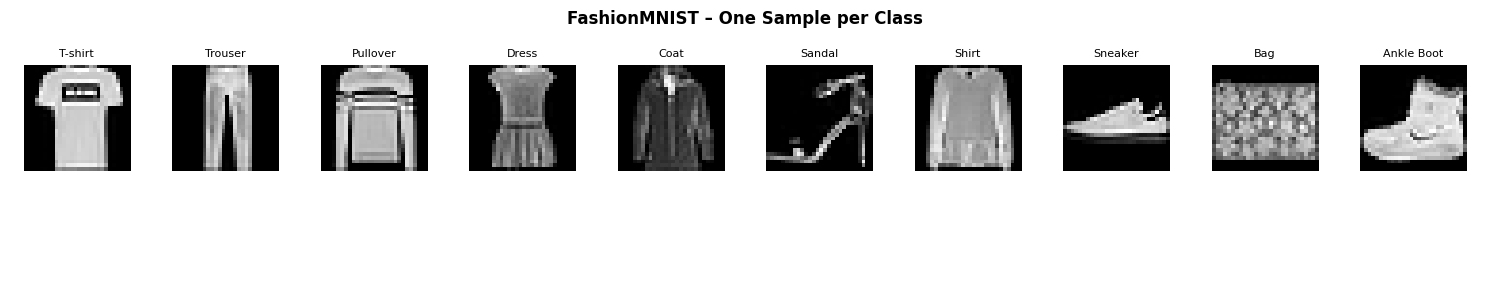

In [3]:
#  Visualising some sample images

def show_sample_grid(dataset, class_names, n=10):
    fig, axes = plt.subplots(2, n, figsize=(15, 3))
    shown = {}
    for img, label in dataset:
        if label not in shown:
            shown[label] = img
        if len(shown) == n:
            break
    for i, (label, img) in enumerate(sorted(shown.items())):
        ax = axes[0, i]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(class_names[label], fontsize=8)
        ax.axis('off')
        axes[1, i].axis('off')
    plt.suptitle('FashionMNIST – One Sample per Class', fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_grid(full_train, CLASS_NAMES)

### 4.4 Model Architecture

In [4]:
class FlexMLP(nn.Module):
    #Flexible Multi-Layer Perceptron 
    def __init__(self, hidden_sizes=[512, 256, 128],
                 dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]          # 28×28 → 784
        in_features = 784

        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(p=dropout_rate))
            in_features = h

        layers.append(nn.Linear(in_features, 10))   # output: 10 classes
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Quick sanity-check 
dummy = FlexMLP(dropout_rate=0.3, use_batchnorm=True)
dummy_input = torch.randn(4, 1, 28, 28)
print("Output shape:", dummy(dummy_input).shape) 
print(dummy)

Output shape: torch.Size([4, 10])
FlexMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=128, out_features=10, bias=True)
  )
)


### 4.5 Training and Evalaution Utilities

In [5]:
def l1_penalty(model, lambda_l1):
    #Compute L1 penalty on all weight tensors (biases excluded).
    penalty = 0.0
    for name, param in model.named_parameters():
        if 'weight' in name:
            penalty += param.abs().sum()
    return lambda_l1 * penalty


def train_one_epoch(model, loader, criterion, optimizer,
                    lambda_l1=0.0):
    #Run one training epoch; returns (avg_loss, accuracy)
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        # Optional L1 penalty added directly to loss
        if lambda_l1 > 0:
            loss = loss + l1_penalty(model, lambda_l1)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    #Evaluate on a DataLoader; returns (avg_loss, accuracy)
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

    return total_loss / total, correct / total


def run_experiment(config, num_epochs=NUM_EPOCHS):
    #To run a full training experiment from a config dict.
    model = FlexMLP(
        hidden_sizes = config.get('hidden_sizes', [512, 256, 128]),
        dropout_rate = config.get('dropout', 0.0),
        use_batchnorm= config.get('batchnorm', False)
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    lr = config.get('lr', LEARNING_RATE)
    wd = config.get('weight_decay', 0.0)

    if config.get('optimizer', 'adam') == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr,
                              momentum=0.9, weight_decay=wd)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    history = defaultdict(list)
    lambda_l1 = config.get('lambda_l1', 0.0)

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, lambda_l1
        )
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  [{config['name']}] Epoch {epoch:>2}/{num_epochs}  "
                  f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.3f}  "
                  f"Val Loss: {va_loss:.4f}  Val Acc: {va_acc:.3f}")

    # Final test accuracy
    _, test_acc = evaluate(model, test_loader, criterion)
    history['test_acc'] = test_acc
    print(f"  [{config['name']}] ** Test Accuracy**: {test_acc:.4f}\n")
    return history

print("Utilities definition completed...")

Utilities definition completed...


### 4.6 Plotting Utiliities

In [6]:
COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22']

def plot_loss_curves(results_dict, title, figsize=(14, 5)):
    #Plot train vs validation loss and accuracy for multiple experiments..
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    epochs = range(1, NUM_EPOCHS + 1)

    for i, (name, hist) in enumerate(results_dict.items()):
        c = COLORS[i % len(COLORS)]
        axes[0].plot(epochs, hist['train_loss'], '--', color=c, alpha=0.6, label=f'{name} [train]')
        axes[0].plot(epochs, hist['val_loss'],   '-',  color=c,            label=f'{name} [val]')
        axes[1].plot(epochs, hist['train_acc'],  '--', color=c, alpha=0.6, label=f'{name} [train]')
        axes[1].plot(epochs, hist['val_acc'],    '-',  color=c,            label=f'{name} [val]')

    axes[0].set_title('Loss (dashed=train, solid=val)')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

    axes[1].set_title('Accuracy (dashed=train, solid=val)')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def make_summary_table(results_dict):
    #Build a summary DataFrame from experiment results.
    rows = []
    for name, hist in results_dict.items():
        best_val_acc = max(hist['val_acc'])
        final_train_acc = hist['train_acc'][-1]
        overfit_gap = final_train_acc - best_val_acc
        rows.append({
            'Experiment'       : name,
            'Final Train Acc'  : f"{final_train_acc:.4f}",
            'Best Val Acc'     : f"{best_val_acc:.4f}",
            'Test Acc'         : f"{hist['test_acc']:.4f}",
            'Overfit Gap (↓)'  : f"{overfit_gap:.4f}",
        })
    return pd.DataFrame(rows).set_index('Experiment')

print("Plot utilities definition completed...")

Plot utilities definition completed...


## 5.Experiments

### 5.1 Overfitting Demonstration (Baseline vs Regularized)
Train a large unregularized network -> Overfit -> Compare with L1,L2,Dropout variants then

In [7]:
#  Experiment 1 configurations
#  All use Adam; hidden sizes kept large to encourage overfitting
exp1_configs = [
    {
        'name'        : 'Baseline (No Reg)',
        'dropout'     : 0.0,
        'batchnorm'   : False,
        'optimizer'   : 'adam',
        'weight_decay': 0.0,
        'lambda_l1'   : 0.0,
        'hidden_sizes': [1024, 512, 256],
        'lr'          : 0.001,
    },
    {
        'name'        : 'L2 Regularization',
        'dropout'     : 0.0,
        'batchnorm'   : False,
        'optimizer'   : 'adam',
        'weight_decay': 1e-3,      # L2 via optimizer weight_decay
        'lambda_l1'   : 0.0,
        'hidden_sizes': [1024, 512, 256],
        'lr'          : 0.001,
    },
    {
        'name'        : 'L1 Regularization',
        'dropout'     : 0.0,
        'batchnorm'   : False,
        'optimizer'   : 'adam',
        'weight_decay': 0.0,
        'lambda_l1'   : 1e-5,      # L1 added manually to loss
        'hidden_sizes': [1024, 512, 256],
        'lr'          : 0.001,
    },
    {
        'name'        : 'Dropout (p=0.4)',
        'dropout'     : 0.4,
        'batchnorm'   : False,
        'optimizer'   : 'adam',
        'weight_decay': 0.0,
        'lambda_l1'   : 0.0,
        'hidden_sizes': [1024, 512, 256],
        'lr'          : 0.001,
    },
]

exp1_results = {}
for cfg in exp1_configs:
    print(f"\n{'**'*65}")
    print(f" Running: {cfg['name']}")
    print(f"{'**'*65}")
    exp1_results[cfg['name']] = run_experiment(cfg)

print("Experiment 1 completed....")


**********************************************************************************************************************************
 Running: Baseline (No Reg)
**********************************************************************************************************************************
  [Baseline (No Reg)] Epoch  1/30  Train Loss: 0.5203  Train Acc: 0.809  Val Loss: 0.4101  Val Acc: 0.850
  [Baseline (No Reg)] Epoch  5/30  Train Loss: 0.2656  Train Acc: 0.899  Val Loss: 0.3436  Val Acc: 0.880
  [Baseline (No Reg)] Epoch 10/30  Train Loss: 0.1935  Train Acc: 0.926  Val Loss: 0.3015  Val Acc: 0.901
  [Baseline (No Reg)] Epoch 15/30  Train Loss: 0.1427  Train Acc: 0.945  Val Loss: 0.3409  Val Acc: 0.901
  [Baseline (No Reg)] Epoch 20/30  Train Loss: 0.1090  Train Acc: 0.958  Val Loss: 0.4173  Val Acc: 0.894
  [Baseline (No Reg)] Epoch 25/30  Train Loss: 0.0882  Train Acc: 0.966  Val Loss: 0.4847  Val Acc: 0.894
  [Baseline (No Reg)] Epoch 30/30  Train Loss: 0.0639  Train Acc: 0.976  

### 5.2: Optimizer Comparison (SGD vs Adam)

We compare SGD (with momentum) vs Adam on the same architecture applying a moderate amount of regularization.

In [8]:
exp2_configs = [
    {
        'name'        : 'Adam (lr=0.001)',
        'dropout'     : 0.3,
        'batchnorm'   : False,
        'optimizer'   : 'adam',
        'weight_decay': 1e-4,
        'lambda_l1'   : 0.0,
        'hidden_sizes': [512, 256, 128],
        'lr'          : 0.001,
    },
    {
        'name'        : 'SGD+Momentum (lr=0.01)',
        'dropout'     : 0.3,
        'batchnorm'   : False,
        'optimizer'   : 'sgd',
        'weight_decay': 1e-4,
        'lambda_l1'   : 0.0,
        'hidden_sizes': [512, 256, 128],
        'lr'          : 0.01,
    },
    {
        'name'        : 'SGD+Momentum (lr=0.001)',
        'dropout'     : 0.3,
        'batchnorm'   : False,
        'optimizer'   : 'sgd',
        'weight_decay': 1e-4,
        'lambda_l1'   : 0.0,
        'hidden_sizes': [512, 256, 128],
        'lr'          : 0.001,
    },
]

exp2_results = {}
for cfg in exp2_configs:
    print(f"\n{'**'*65}")
    print(f" Running: {cfg['name']}")
    print(f"{'**'*65}")
    exp2_results[cfg['name']] = run_experiment(cfg)

print("Experiment 2 completed...")


**********************************************************************************************************************************
 Running: Adam (lr=0.001)
**********************************************************************************************************************************
  [Adam (lr=0.001)] Epoch  1/30  Train Loss: 0.6442  Train Acc: 0.767  Val Loss: 0.4145  Val Acc: 0.851
  [Adam (lr=0.001)] Epoch  5/30  Train Loss: 0.3403  Train Acc: 0.877  Val Loss: 0.3308  Val Acc: 0.877
  [Adam (lr=0.001)] Epoch 10/30  Train Loss: 0.2908  Train Acc: 0.891  Val Loss: 0.3143  Val Acc: 0.886
  [Adam (lr=0.001)] Epoch 15/30  Train Loss: 0.2639  Train Acc: 0.903  Val Loss: 0.3119  Val Acc: 0.888
  [Adam (lr=0.001)] Epoch 20/30  Train Loss: 0.2407  Train Acc: 0.910  Val Loss: 0.3026  Val Acc: 0.896
  [Adam (lr=0.001)] Epoch 25/30  Train Loss: 0.2266  Train Acc: 0.915  Val Loss: 0.2868  Val Acc: 0.900
  [Adam (lr=0.001)] Epoch 30/30  Train Loss: 0.2185  Train Acc: 0.918  Val Loss: 0.2979

### 5.3: Batch Normalization Effect

In [9]:
exp3_configs = [
    {
        'name'        : 'No BatchNorm',
        'dropout'     : 0.0,
        'batchnorm'   : False,
        'optimizer'   : 'adam',
        'weight_decay': 0.0,
        'lambda_l1'   : 0.0,
        'hidden_sizes': [512, 256, 128],
        'lr'          : 0.001,
    },
    {
        'name'        : 'With BatchNorm',
        'dropout'     : 0.0,
        'batchnorm'   : True,
        'optimizer'   : 'adam',
        'weight_decay': 0.0,
        'lambda_l1'   : 0.0,
        'hidden_sizes': [512, 256, 128],
        'lr'          : 0.001,
    },
    {
        'name'        : 'BatchNorm + Dropout',
        'dropout'     : 0.3,
        'batchnorm'   : True,
        'optimizer'   : 'adam',
        'weight_decay': 1e-4,
        'lambda_l1'   : 0.0,
        'hidden_sizes': [512, 256, 128],
        'lr'          : 0.001,
    },
]

exp3_results = {}
for cfg in exp3_configs:
    print(f"\n{'**'*65}")
    print(f" Running: {cfg['name']}")
    print(f"{'**'*65}")
    exp3_results[cfg['name']] = run_experiment(cfg)

print("Experiment 3 completed....")


**********************************************************************************************************************************
 Running: No BatchNorm
**********************************************************************************************************************************
  [No BatchNorm] Epoch  1/30  Train Loss: 0.5523  Train Acc: 0.803  Val Loss: 0.3968  Val Acc: 0.858
  [No BatchNorm] Epoch  5/30  Train Loss: 0.2768  Train Acc: 0.897  Val Loss: 0.3154  Val Acc: 0.884
  [No BatchNorm] Epoch 10/30  Train Loss: 0.2045  Train Acc: 0.923  Val Loss: 0.3075  Val Acc: 0.892
  [No BatchNorm] Epoch 15/30  Train Loss: 0.1598  Train Acc: 0.939  Val Loss: 0.3307  Val Acc: 0.895
  [No BatchNorm] Epoch 20/30  Train Loss: 0.1232  Train Acc: 0.953  Val Loss: 0.3788  Val Acc: 0.897
  [No BatchNorm] Epoch 25/30  Train Loss: 0.0972  Train Acc: 0.963  Val Loss: 0.4257  Val Acc: 0.895
  [No BatchNorm] Epoch 30/30  Train Loss: 0.0790  Train Acc: 0.970  Val Loss: 0.4775  Val Acc: 0.897
  [No B

## 6. Results

### 6.1  Regularization Comparison (Exp 5.1)

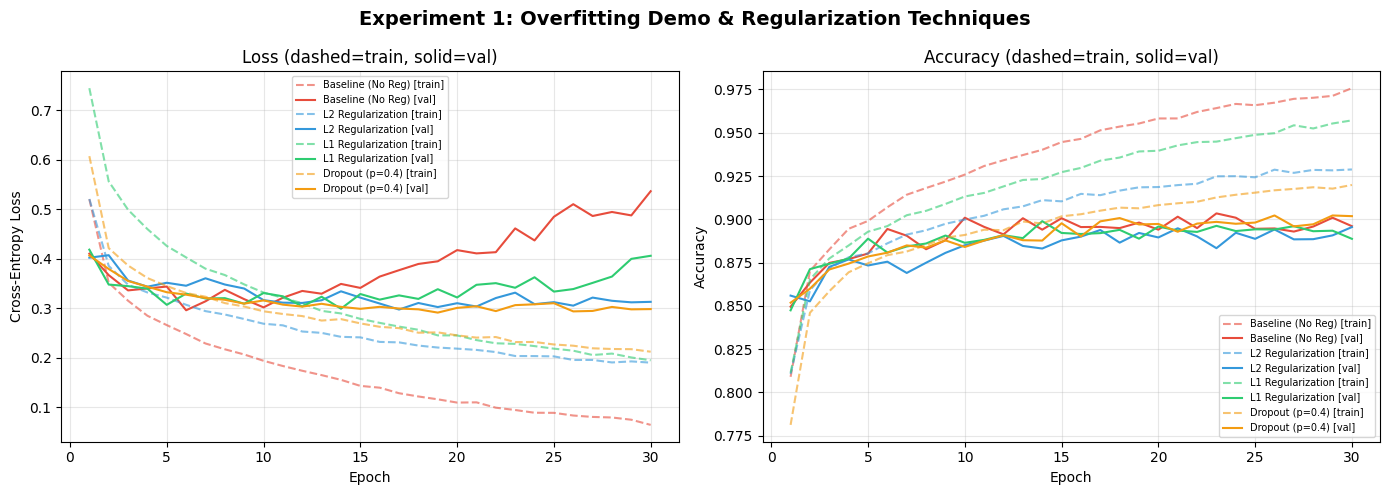


 Summary Table – Experiment 1


,Final Train Acc,Best Val Acc,Test Acc,Overfit Gap (↓)
Experiment,,,,
Baseline (No Reg),0.9757,0.9034,0.8913,0.0723
L2 Regularization,0.9288,0.8955,0.8854,0.0333
L1 Regularization,0.9571,0.8989,0.8801,0.0582
Dropout (p=0.4),0.9198,0.9022,0.8949,0.0176


In [10]:
plot_loss_curves(exp1_results,
    title='Experiment 1: Overfitting Demo & Regularization Techniques')

print("\n Summary Table – Experiment 1")
display(make_summary_table(exp1_results))

### 6.2  Optimizer Comparison (Exp 5.2)

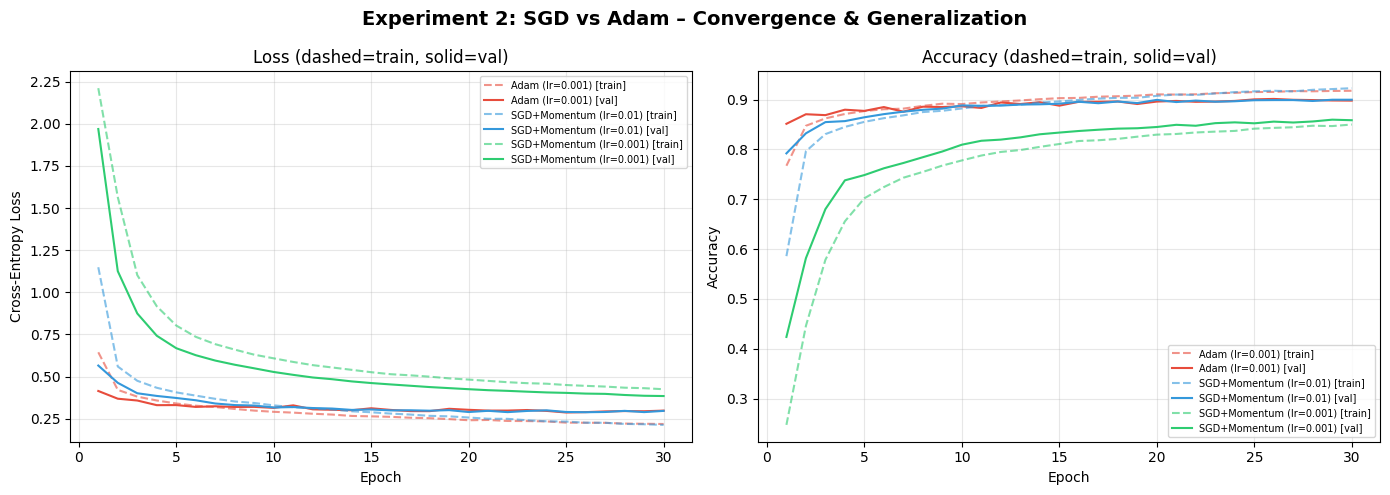


 Summary Table – Experiment 2


,Final Train Acc,Best Val Acc,Test Acc,Overfit Gap (↓)
Experiment,,,,
Adam (lr=0.001),0.9176,0.9012,0.8894,0.0164
SGD+Momentum (lr=0.01),0.9228,0.8996,0.8906,0.0232
SGD+Momentum (lr=0.001),0.8499,0.8596,0.8503,-0.0097


In [11]:
plot_loss_curves(exp2_results,
    title='Experiment 2: SGD vs Adam – Convergence & Generalization')

print("\n Summary Table – Experiment 2")
display(make_summary_table(exp2_results))

### 6.3 Batch Normalization(Exp 5.3)

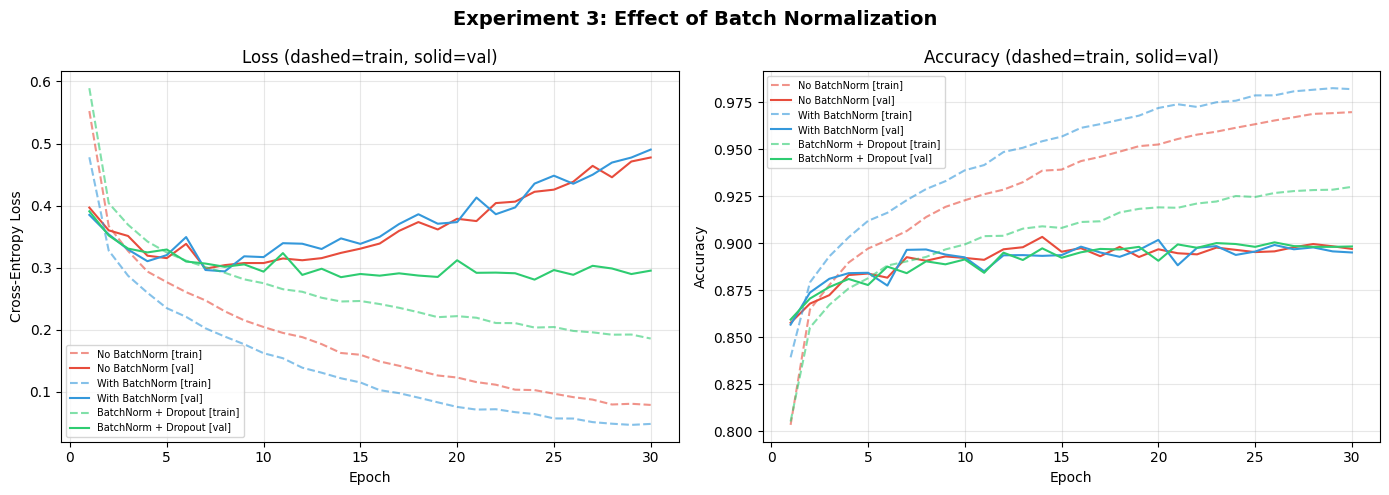


 Summary Table – Experiment 3


,Final Train Acc,Best Val Acc,Test Acc,Overfit Gap (↓)
Experiment,,,,
No BatchNorm,0.9698,0.9034,0.8907,0.0664
With BatchNorm,0.9820,0.9018,0.8802,0.0802
BatchNorm + Dropout,0.9300,0.9005,0.8892,0.0295


In [12]:
plot_loss_curves(exp3_results,
    title='Experiment 3: Effect of Batch Normalization')

print("\n Summary Table – Experiment 3")
display(make_summary_table(exp3_results))

### 6.4 Summary Bar Chart

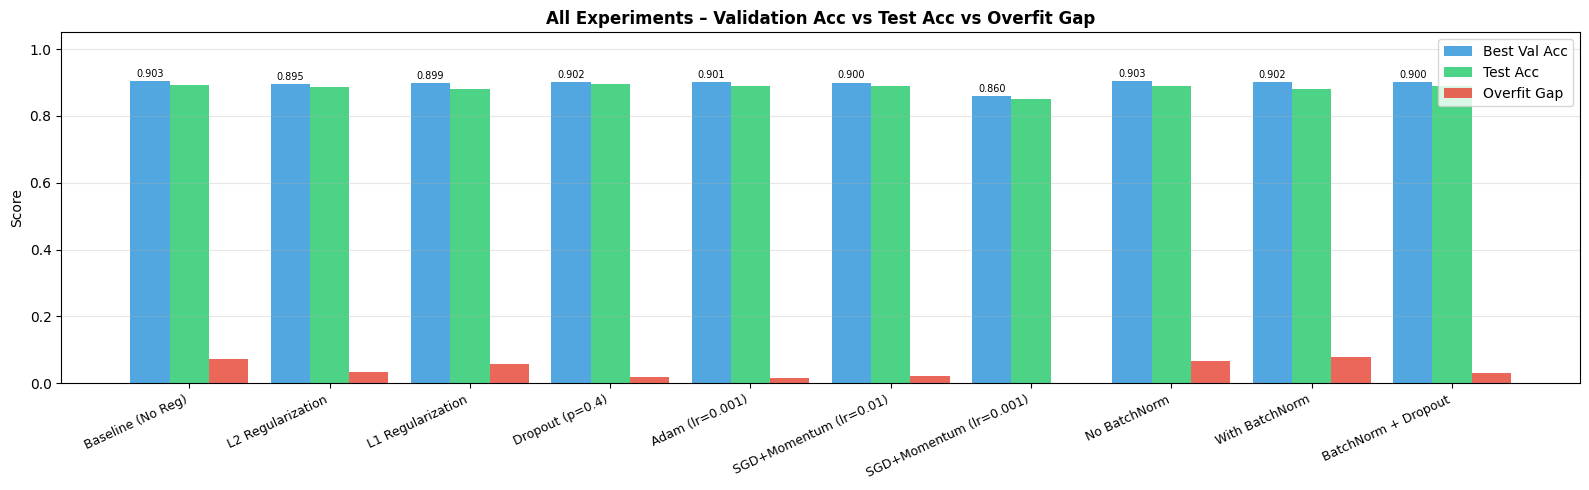

In [13]:
all_results = {**exp1_results, **exp2_results, **exp3_results}

names   = list(all_results.keys())
val_acc = [max(h['val_acc'])        for h in all_results.values()]
tst_acc = [h['test_acc']            for h in all_results.values()]
gap     = [h['train_acc'][-1] - max(h['val_acc']) for h in all_results.values()]

x = np.arange(len(names))
width = 0.28

fig, ax = plt.subplots(figsize=(16, 5))
bars1 = ax.bar(x - width, val_acc, width, label='Best Val Acc',  color='#3498db', alpha=0.85)
bars2 = ax.bar(x,         tst_acc, width, label='Test Acc',       color='#2ecc71', alpha=0.85)
bars3 = ax.bar(x + width, gap,     width, label='Overfit Gap',    color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('All Experiments – Validation Acc vs Test Acc vs Overfit Gap',
             fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=7)

plt.tight_layout()
plt.show()

## 7 Analysis and Discussion

### 7.1 Overfitting (Experiment 1)
The baseline model showed textbook overfitting as the training accuracy climbed to 97.6% while validation accuracy plateaued around 90.3%, giving an overfit gap of 0.072, the largest of
all models tested.<br>
L2 regularization cut that gap almost in half (down to 0.033),while keeping training and validation
accuracy much closer together.<br>
L1 was similar but slightly less effective here, with a gap of 0.058 , it also took longer to get going, with higher early training loss due to the manually defined penalty.<br>
Dropout (p=0.4) worked best out of the three, bringing the overfit gap all the way down to 0.018 while still reaching 89.5% test accuracy.

### 7.2 Optimizer Comparison (Experiment 2)
Adam started strong — by epoch 5 it was already at 87.7% val accuracy, while SGD (lr=0.01) was still at 86.4%.<br>
However, SGD caught up over time and by epoch 30 they were essentially equal (SGD: 90.0%, Adam: 89.8%). <br>
So Adam has win on speed, but SGD is competitive in the end with the right learning rate. <br>
SGD at lr=0.001 was a different story with still only at 85% by epoch 30, confirming how sensitive SGD is with the learning rte.

### 7.3 Batch Normalization (Experiment 3)
BatchNorm did make training faster as the model jumped to 83.9% accuracy in epoch 1 vs 80.3% without it. <br>
However, BatchNorm alone actually produced a worse overfit gap (0.080) than the baseline without it (0.066). It pushed training accuracy
very high (98.2%) without a matching improvement in validation. <br>
So in this case, BatchNormhelped convergence speed but not generalization on its own.<br>
Combining BatchNorm with Dropout fixed this problem, the overfit gap dropped to 0.030, which meant it gave  a much healthier balance between training and validation performance.<br>

### 7.4 Trade-offs
- L2 is the easiest to apply and gave a solid reduction in overfitting.
- L1 is useful for sparsity but harder to tune and had a slower start.
- Dropout was the most effective regularizer overall but slows training down.
- BatchNorm alone actually increased the overfit gap in our run — it needs to be paired with Dropout to be effective as a regularizer. 
- Adam is faster to converge, but given enough epochs, SGD with momentum (lr=0.01) also matched it.

## 8. Conclusion
- Overfitting was clearly visible in the baseline with a 7.2% gap between training and validation accuracy had confirmed the need for regularization.
- Dropout reduced overfitting the most (gap: 0.018) and had achieved the best test accuracy (89.5%) among all Experiment 1 models.
- L2 was the easiest regularizer to apply and meaningfully reduced the overfit gap. L1 performed similarly but was comparatively harder to tune.
- Adam converged faster early on, but SGD with momentum (lr=0.01) matched its final accuracy by epoch 30. Learning rate choice seemed to matter a lot for SGD.
- BatchNorm alone did not reduce overfitting in our experiments — it actually increased theoverfit gap. Pairing it with Dropout gave the best balance of convergence speed and generalization.